#  Phase 2: Exploratory Data Analysis
**DSA 210 — Spring 2026 | Zeynep Altundal | 31978 | Sabancı University**

---

## 📌 Notebook Overview
This notebook covers **Exploratory Data Analysis** of the US Accidents dataset.
Analyzing accident patterns across time, weather, location, and road features.

**Input:** US_Accidents_March23.csv (run after notebook 1 or re-run setup cells)
**Output:** 12 visualizations saved to `figures/eda/`

### Environment Setup
Installing required libraries:
-  Kaggle API client for dataset download
-  statsmodels statistical tests (proportion z-test)

In [ ]:
!pip install kaggle statsmodels -q

In [ ]:
import os, json

kaggle_creds = {
    "username": "#######",
    "key": "#######"
}

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json
print("Done")

Done


In [ ]:
!kaggle datasets download -d sobhanmoosavi/us-accidents
!unzip -q us-accidents.zip
!ls *.csv

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:03<00:00, 217MB/s]

US_Accidents_March23.csv


###  Library Imports & Configuration
Loading all required libraries for data manipulation, visualization, and statistical testing.
Setting global plot style and creating the `figures/` directory for saving outputs.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
os.makedirs("figures", exist_ok=True)
print(" Libraries loaded!")

 Libraries loaded!


###  Data Loading & Sampling
The full dataset contains **7,728,394 records** across 46 features.
We take a reproducible random sample of **500,000 records** (random_state=42) —
statistically representative while keeping computation feasible on Colab.

In [ ]:
print("Loading dataset... (may take ~1 min)")
df_full = pd.read_csv("US_Accidents_March23.csv", low_memory=False)
print(f"Full dataset: {df_full.shape}")

df = df_full.sample(n=500_000, random_state=42).copy()
del df_full
print(f" Working sample: {df.shape}")
df.head(3)

Loading dataset... (may take ~1 min)
Full dataset: (7728394, 46)
 Working sample: (500000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7133276,A-7182628,Source1,1,2020-04-17 09:29:30,2020-04-17 10:29:30,26.706900,-80.119360,26.706900,-80.119360,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
5363845,A-5404588,Source1,2,2022-04-21 10:01:00.000000000,2022-04-21 11:44:08.000000000,38.781024,-121.265820,38.780377,-121.265815,0.045,...,False,False,True,False,False,False,Day,Day,Day,Day
155993,A-156000,Source3,3,2016-08-12 16:45:00,2016-08-12 17:15:00,33.985249,-84.269348,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day


### Preprocessing
Cleaning the data and engineering new features for analysis.

| Step | Description |
|------|-------------|
| Timestamp parsing | Extract Hour, DayOfWeek, Month, Year, IsWeekend |
| Duration | Compute accident duration in minutes |
| TimeOfDay | Morning (6-12) / Afternoon (12-17) / Evening (17-21) / Night |
| HighRisk label | Binary: Severity ≥ 3 → 1, else → 0 |
| Missing values | Drop rows missing Severity, Hour, Weather, Temperature |
| Temperature | Remove physically impossible values (< -50°F or > 130°F) |
| Weather | Map 100+ raw conditions → 8 broad categories |

In [ ]:
# Parse timestamps
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["End_Time"]   = pd.to_datetime(df["End_Time"],   errors="coerce")

# Temporal features
df["Hour"]      = df["Start_Time"].dt.hour
df["DayOfWeek"] = df["Start_Time"].dt.day_name()
df["Month"]     = df["Start_Time"].dt.month
df["Year"]      = df["Start_Time"].dt.year
df["IsWeekend"] = df["Start_Time"].dt.dayofweek >= 5

# Duration
df["Duration_min"] = (df["End_Time"] - df["Start_Time"]).dt.total_seconds() / 60

# Time of day buckets
def time_of_day(hour):
    if 6 <= hour < 12:   return "Morning"
    elif 12 <= hour < 17: return "Afternoon"
    elif 17 <= hour < 21: return "Evening"
    else:                 return "Night"

df["TimeOfDay"] = df["Hour"].apply(time_of_day)

# High risk binary label (Severity 3 or 4)
df["HighRisk"] = (df["Severity"] >= 3).astype(int)

# Drop rows missing key columns
key_cols = ["Severity", "Hour", "Start_Time", "Weather_Condition", "Temperature(F)"]
before = len(df)
df.dropna(subset=key_cols, inplace=True)
df = df[(df["Temperature(F)"] > -50) & (df["Temperature(F)"] < 130)]
print(f"Dropped {before - len(df):,} rows → Final: {len(df):,} rows")

# Simplify weather conditions
weather_map = {
    "Clear": ["Clear", "Fair"],
    "Cloudy": ["Cloudy", "Overcast", "Mostly Cloudy", "Partly Cloudy", "Scattered Clouds"],
    "Rain": ["Rain", "Light Rain", "Heavy Rain", "Drizzle", "Showers", "Light Drizzle"],
    "Snow": ["Snow", "Light Snow", "Heavy Snow", "Blowing Snow", "Sleet"],
    "Fog":  ["Fog", "Haze", "Mist", "Smoke", "Patches of Fog"],
    "Storm":["Thunderstorm", "Thunder", "Squalls"],
    "Wind": ["Windy", "Breezy", "Blowing Dust"],
}

def map_weather(cond):
    if pd.isna(cond): return "Other"
    for cat, kws in weather_map.items():
        if any(k.lower() in str(cond).lower() for k in kws):
            return cat
    return "Other"

df["WeatherCategory"] = df["Weather_Condition"].apply(map_weather)

print(f"\nSeverity distribution:\n{df['Severity'].value_counts().sort_index()}")
print(f"\nHigh-risk rate: {df['HighRisk'].mean()*100:.1f}%")
print(" Preprocessing done!")

Dropped 59,682 rows → Final: 440,318 rows

Severity distribution:
Severity
1      4319
2    342267
3     82262
4     11470
Name: count, dtype: int64

High-risk rate: 21.3%
 Preprocessing done!


###  Preprocessing Results
- **Dropped:** 59,682 rows with missing or invalid values (11.9% of sample)
- **Final sample:** 440,318 records ready for analysis
- **Severity breakdown:** Severity 1 → 1% | 2 → 78% | 3 → 19% | 4 → 2.6%
- **High-risk rate:** 21.3% of accidents are Severity 3 or 4
- **Note:** End_Lat/End_Lng has 44% missing values dataset-wide — not used in this phase
- **Note:** Precipitation(in) has 28% missing — will be handled in Phase 3

##  Exploratory Data Analysis — Panel 1: Temporal & Weather Patterns
Analyzing how accidents distribute across time (hour, day, month) and weather conditions.
Examining high-risk rate by time of day to identify the most dangerous periods.

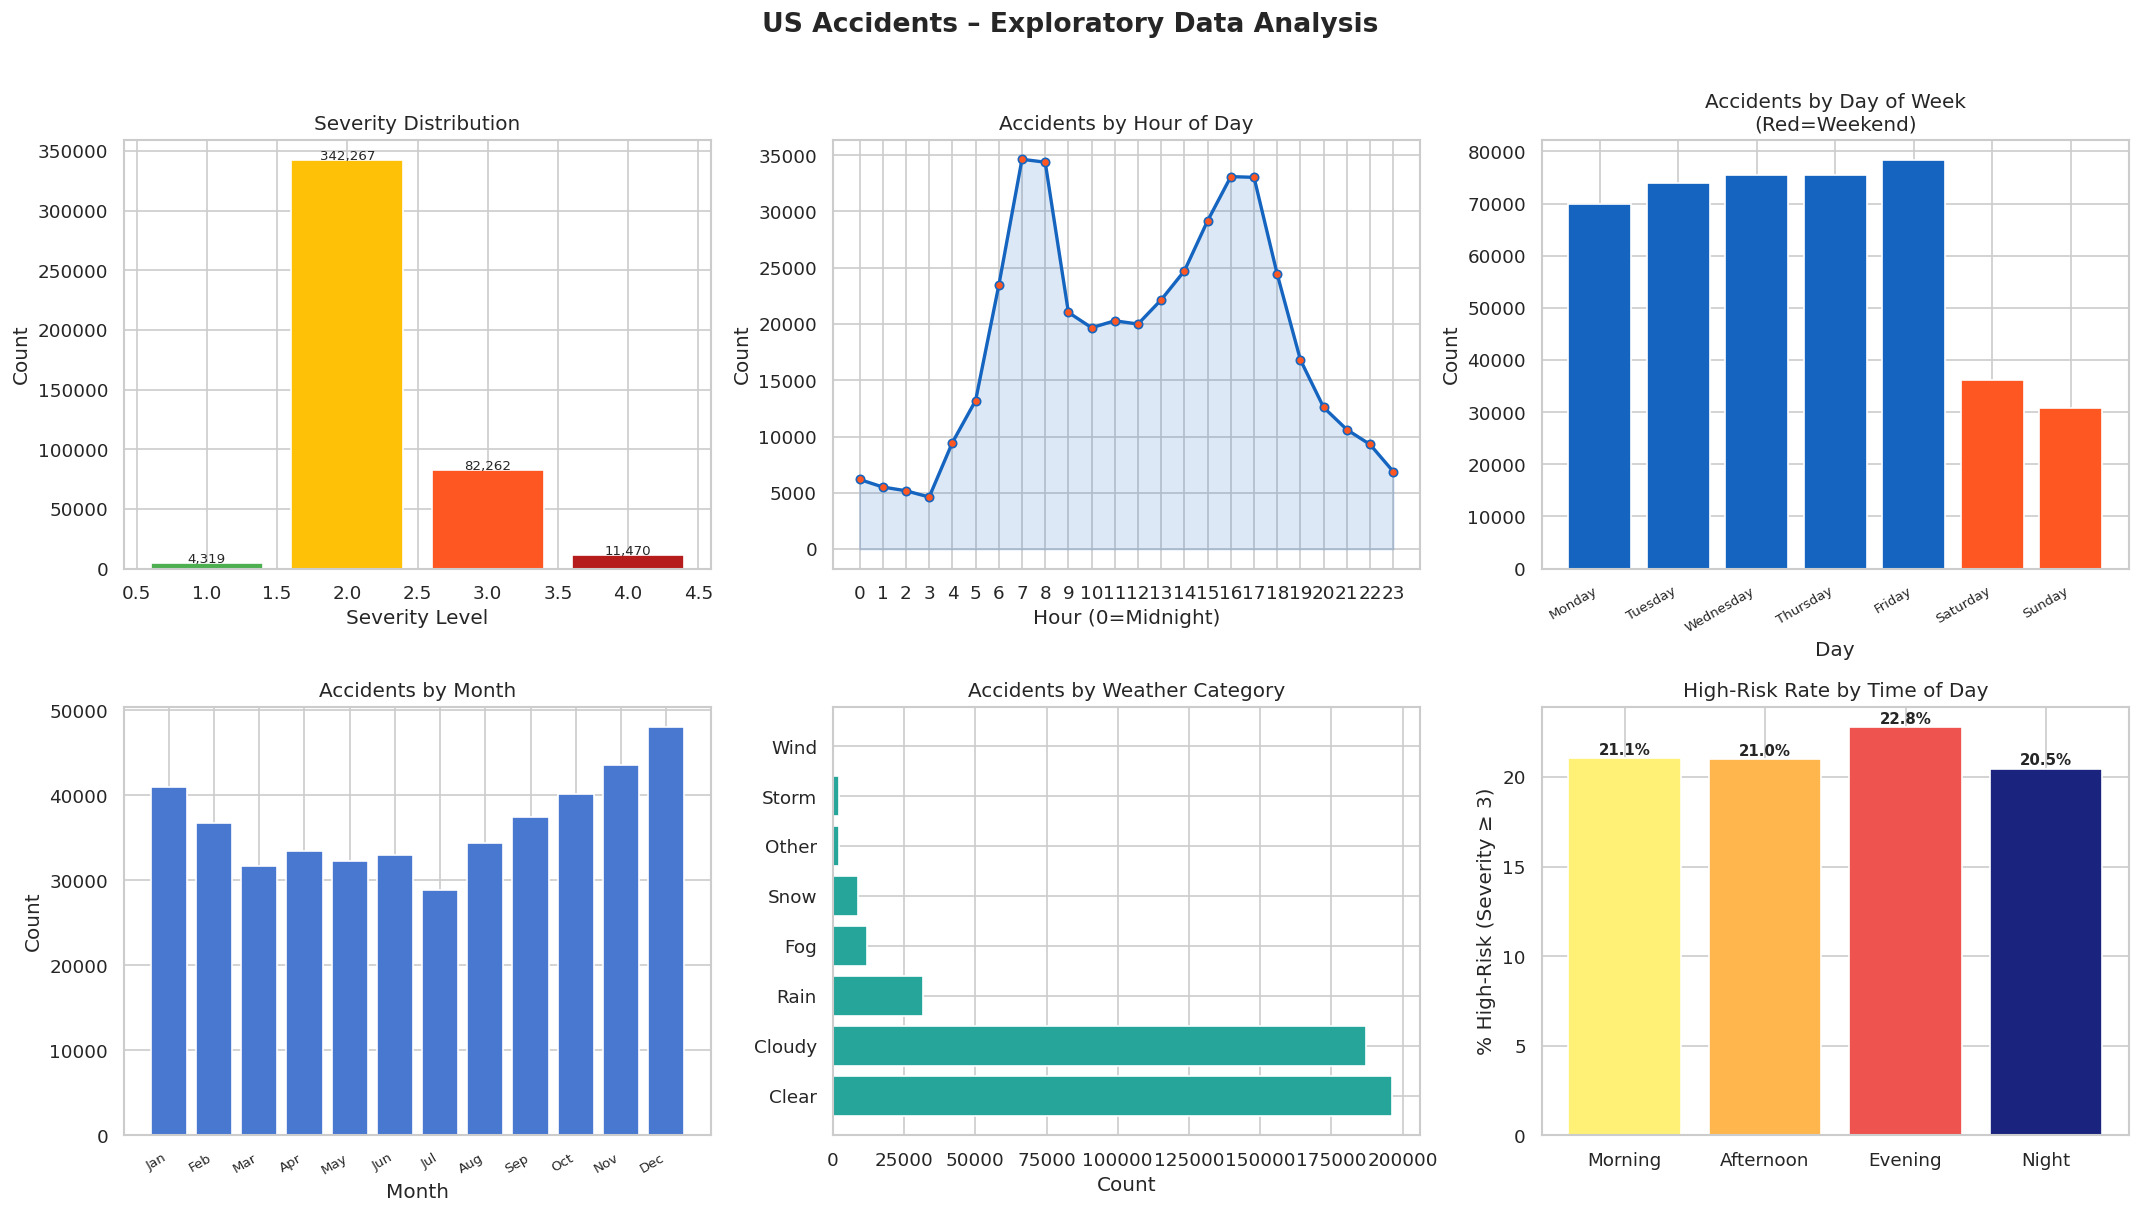

 Panel 1 saved!


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("US Accidents – Exploratory Data Analysis", fontsize=16, fontweight="bold", y=1.01)

# 1) Severity Distribution
ax = axes[0, 0]
sev_counts = df["Severity"].value_counts().sort_index()
bars = ax.bar(sev_counts.index, sev_counts.values,
              color=["#4CAF50","#FFC107","#FF5722","#B71C1C"], edgecolor="white")
ax.set_title("Severity Distribution")
ax.set_xlabel("Severity Level")
ax.set_ylabel("Count")
for b, v in zip(bars, sev_counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+500, f"{v:,}", ha="center", fontsize=8)

# 2) Accidents by Hour
ax = axes[0, 1]
hour_counts = df["Hour"].value_counts().sort_index()
ax.plot(hour_counts.index, hour_counts.values, marker="o", color="#1565C0",
        markerfacecolor="#FF5722", linewidth=2, markersize=5)
ax.fill_between(hour_counts.index, hour_counts.values, alpha=0.15, color="#1565C0")
ax.set_title("Accidents by Hour of Day")
ax.set_xlabel("Hour (0=Midnight)")
ax.set_ylabel("Count")
ax.set_xticks(range(0,24))

# 3) Accidents by Day of Week
ax = axes[0, 2]
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts = df["DayOfWeek"].value_counts().reindex(day_order)
colors = ["#FF5722" if d in ["Saturday","Sunday"] else "#1565C0" for d in day_order]
ax.bar(day_order, day_counts.values, color=colors, edgecolor="white")
ax.set_title("Accidents by Day of Week\n(Red=Weekend)")
ax.set_xlabel("Day")
ax.set_ylabel("Count")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

# 4) Accidents by Month
ax = axes[1, 0]
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_counts = df["Month"].value_counts().sort_index()
ax.bar([month_names[int(i)-1] for i in month_counts.index], month_counts.values,)
ax.set_title("Accidents by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Count")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)

# 5) Weather Category Distribution
ax = axes[1, 1]
wc = df["WeatherCategory"].value_counts()
ax.barh(wc.index, wc.values, color="#26A69A", edgecolor="white")
ax.set_title("Accidents by Weather Category")
ax.set_xlabel("Count")

# 6) High-Risk Rate by Time of Day
ax = axes[1, 2]
tod_order = ["Morning","Afternoon","Evening","Night"]
tod_risk = df.groupby("TimeOfDay")["HighRisk"].mean().reindex(tod_order) * 100
bar_colors = ["#FFF176","#FFB74D","#EF5350","#1A237E"]
bars = ax.bar(tod_risk.index, tod_risk.values, color=bar_colors, edgecolor="white")
ax.set_title("High-Risk Rate by Time of Day")
ax.set_ylabel("% High-Risk (Severity ≥ 3)")
for b, v in zip(bars, tod_risk.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2, f"{v:.1f}%",
            ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_panel1.png", bbox_inches="tight")
plt.show()
print(" Panel 1 saved!")

###  Panel 1 Key Findings
- **Peak hours:** 8 AM and 5 PM — driven by morning and evening commuter rush hours
- **Weekdays vs weekends:** Weekdays have ~2× more accidents — traffic volume effect
- **Seasonal pattern:** November–December highest — winter weather + holiday travel
- **Evening:** Highest high-risk rate at **22.8%** — reduced visibility and driver fatigue
- **Weather exposure:** Most accidents occur in Clear/Cloudy conditions due to higher exposure frequency, but adverse weather increases *risk per exposure*

##  Exploratory Data Analysis — Panel 2: Correlations & Road Features
Deep-diving into weather × severity interactions, numeric feature correlations,
and how road infrastructure (junctions, traffic signals, etc.) affects accident risk.

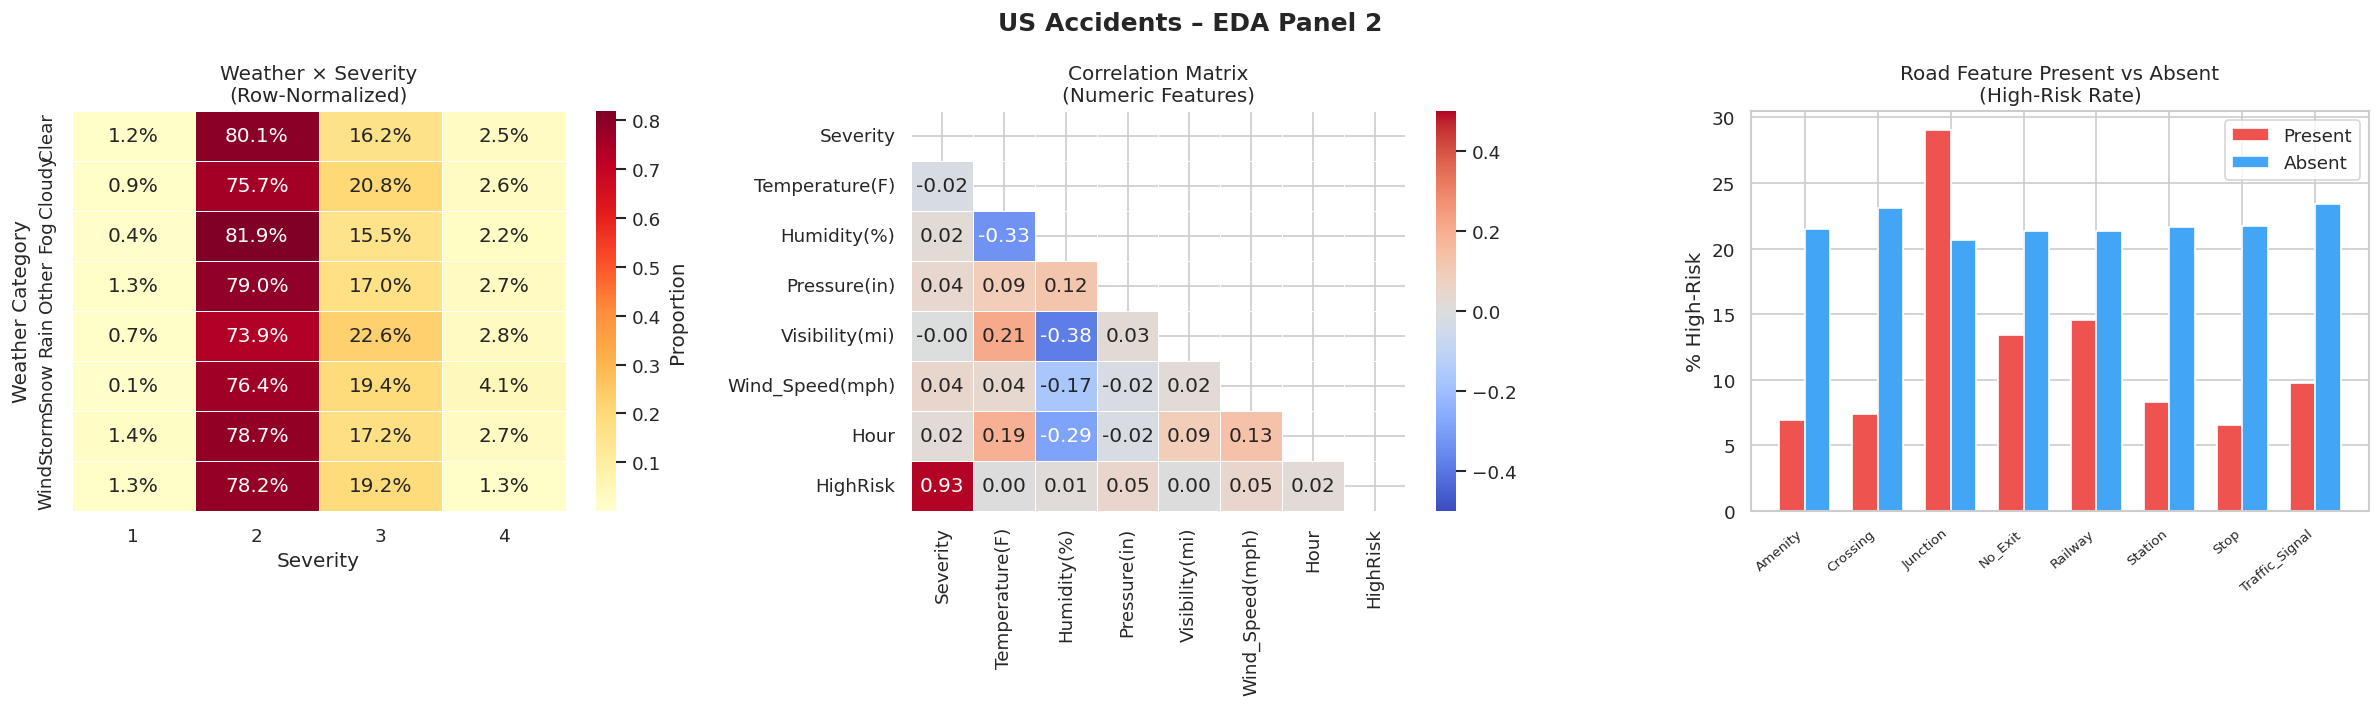

 Panel 2 saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("US Accidents – EDA Panel 2", fontsize=15, fontweight="bold")

# 7) Weather × Severity Heatmap
ax = axes[0]
pivot = df.groupby(["WeatherCategory","Severity"]).size().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
sns.heatmap(pivot_norm, annot=True, fmt=".1%", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label":"Proportion"})
ax.set_title("Weather × Severity\n(Row-Normalized)")
ax.set_xlabel("Severity")
ax.set_ylabel("Weather Category")

# 8) Correlation Heatmap
ax = axes[1]
numeric_cols = ["Severity","Temperature(F)","Humidity(%)","Pressure(in)",
                "Visibility(mi)","Wind_Speed(mph)","Hour","HighRisk"]
numeric_cols = [c for c in numeric_cols if c in df.columns]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, vmin=-0.5, vmax=0.5)
ax.set_title("Correlation Matrix\n(Numeric Features)")

# 9) Road Features vs High-Risk Rate
ax = axes[2]
road_features = ["Amenity","Crossing","Junction","No_Exit",
                 "Railway","Station","Stop","Traffic_Signal"]
road_features = [f for f in road_features if f in df.columns]
present_risk = [df[df[f].astype(bool)]["HighRisk"].mean()*100 for f in road_features]
absent_risk  = [df[~df[f].astype(bool)]["HighRisk"].mean()*100 for f in road_features]

x = np.arange(len(road_features))
width = 0.35
ax.bar(x - width/2, present_risk, width, label="Present", color="#EF5350", edgecolor="white")
ax.bar(x + width/2, absent_risk,  width, label="Absent",  color="#42A5F5", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(road_features, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("% High-Risk")
ax.set_title("Road Feature Present vs Absent\n(High-Risk Rate)")
ax.legend()

plt.tight_layout()
plt.savefig("figures/eda_panel2.png", bbox_inches="tight")
plt.show()
print(" Panel 2 saved!")

###  Panel 2 Key Findings
- **Snow/Rain → higher severity:** Adverse weather meaningfully increases accident severity compared to Clear conditions
- **Junction danger:** High-risk rate jumps to ~29% when a junction is present vs ~21% without — intersections are danger zones
- **Traffic signals reduce risk:** Accidents near traffic signals are *less* likely to be high-risk — signals regulate traffic flow
- **Correlation:** Humidity and Visibility negatively correlate (-0.38) — confirming physical relationship between moisture and visibility

##  EDA — Panel 3: Geographic Distribution
Visualizing accident locations across the US using GPS coordinates (Start_Lat, Start_Lng).
Color represents severity level. Top 10 states ranked by accident count with average severity.
Note: 50K sample used for scatter map performance.

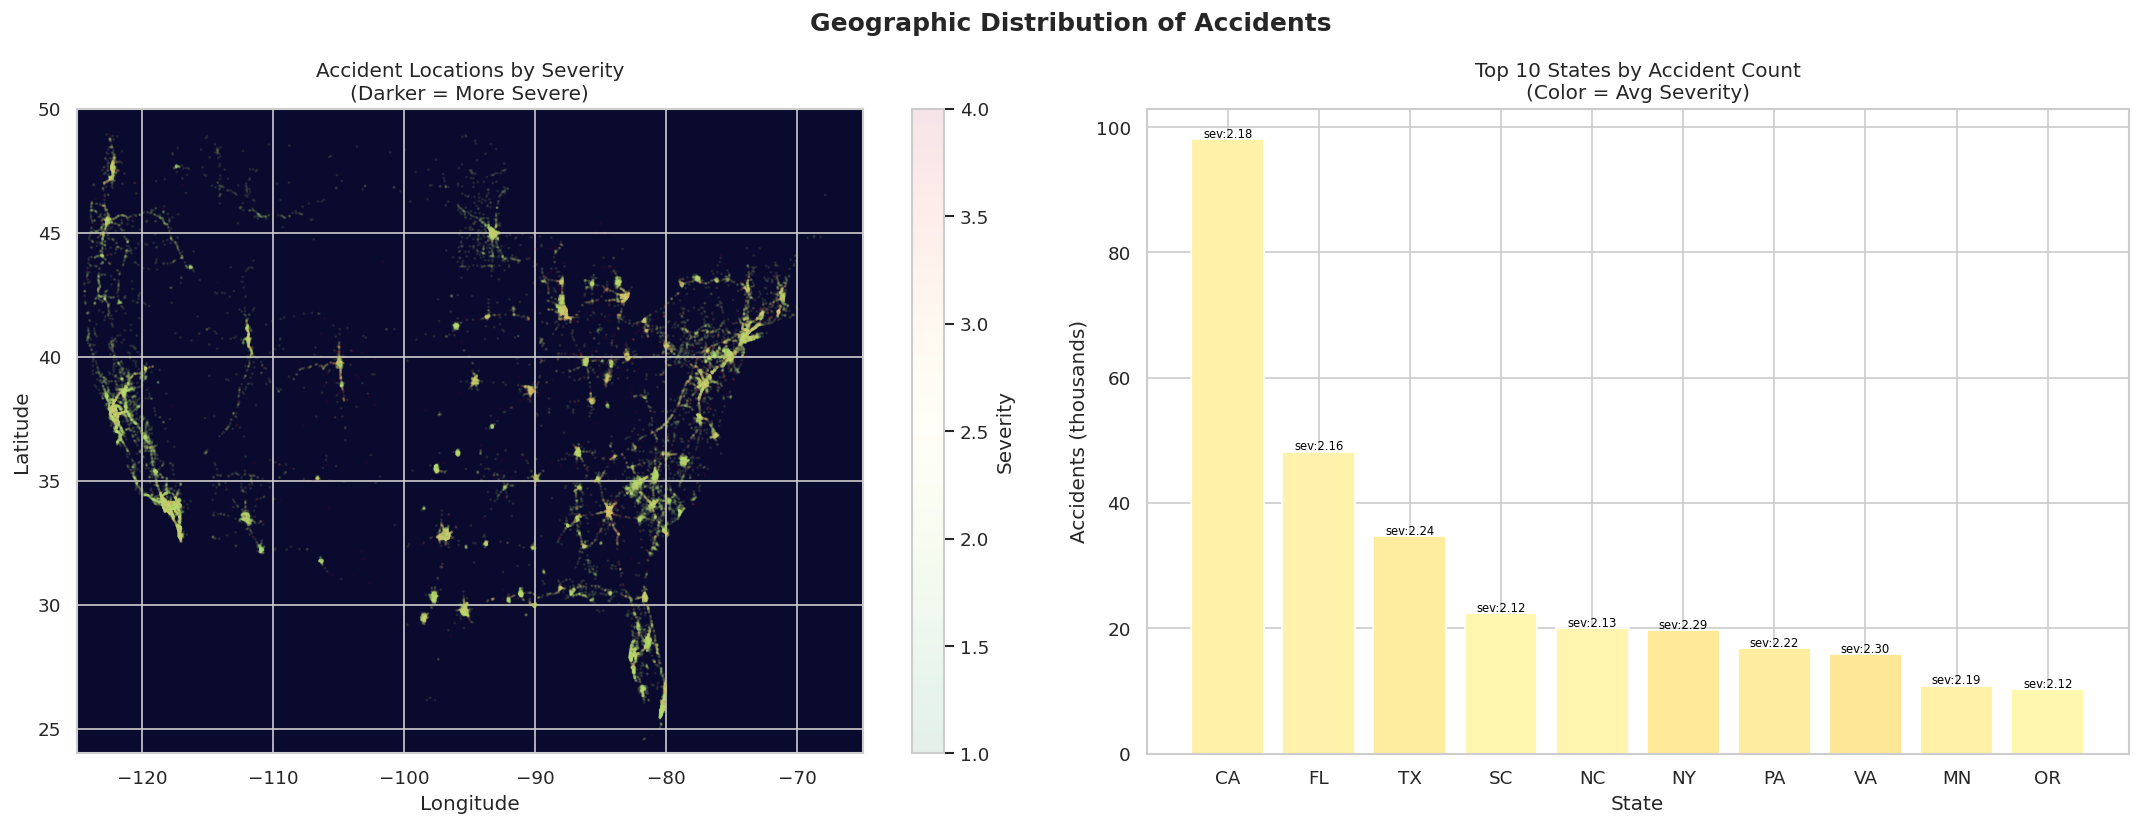

 Geographic panel saved!


In [ ]:
# Geographic density map of accidents across the US
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Geographic Distribution of Accidents", fontsize=15, fontweight="bold")

# 1) Accident density scatter map
ax = axes[0]
# Sample 50K for performance
map_sample = df[["Start_Lat","Start_Lng","Severity"]].dropna().sample(50000, random_state=42)
scatter = ax.scatter(
    map_sample["Start_Lng"], map_sample["Start_Lat"],
    c=map_sample["Severity"], cmap="RdYlGn_r",
    alpha=0.1, s=0.5
)
ax.set_xlim(-125, -65)
ax.set_ylim(24, 50)
ax.set_facecolor("#0a0a2e")
fig.colorbar(scatter, ax=ax, label="Severity")
ax.set_title("Accident Locations by Severity\n(Darker = More Severe)", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# 2) Top 10 states bar chart
ax = axes[1]
if "State" in df.columns:
    top_states = df.groupby("State").agg(
        count=("Severity","count"),
        avg_severity=("Severity","mean")
    ).nlargest(10, "count").reset_index()

    bars = ax.bar(top_states["State"], top_states["count"]/1000,
                  color=plt.cm.RdYlGn_r(top_states["avg_severity"]/4),
                  edgecolor="white")
    ax.set_title("Top 10 States by Accident Count\n(Color = Avg Severity)", fontsize=12)
    ax.set_xlabel("State")
    ax.set_ylabel("Accidents (thousands)")

    # Add avg severity labels
    for bar, sev in zip(bars, top_states["avg_severity"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f"sev:{sev:.2f}", ha="center", fontsize=7, color="black")

plt.tight_layout()
plt.savefig("figures/eda_panel3_geographic.png", bbox_inches="tight", dpi=150)
plt.show()
print(" Geographic panel saved!")

###  Panel 3 Key Findings
- **California, Florida, Texas** are the top 3 states by accident count — largest population + road network
- **Color pattern:** Accidents cluster heavily on the East Coast and major highway corridors
- **Severity by state:** Average severity varies across states — reflects differences in road types and reporting

##  EDA — Panel 4: Advanced Severity Analysis
Three complementary views of severity patterns:
1. **Boxplot:** Severity distribution by weather category
2. **Yearly trend:** Accident count and high-risk rate from 2016 to 2023
3. **Rush hour:** Severity distribution comparison between rush and non-rush hours

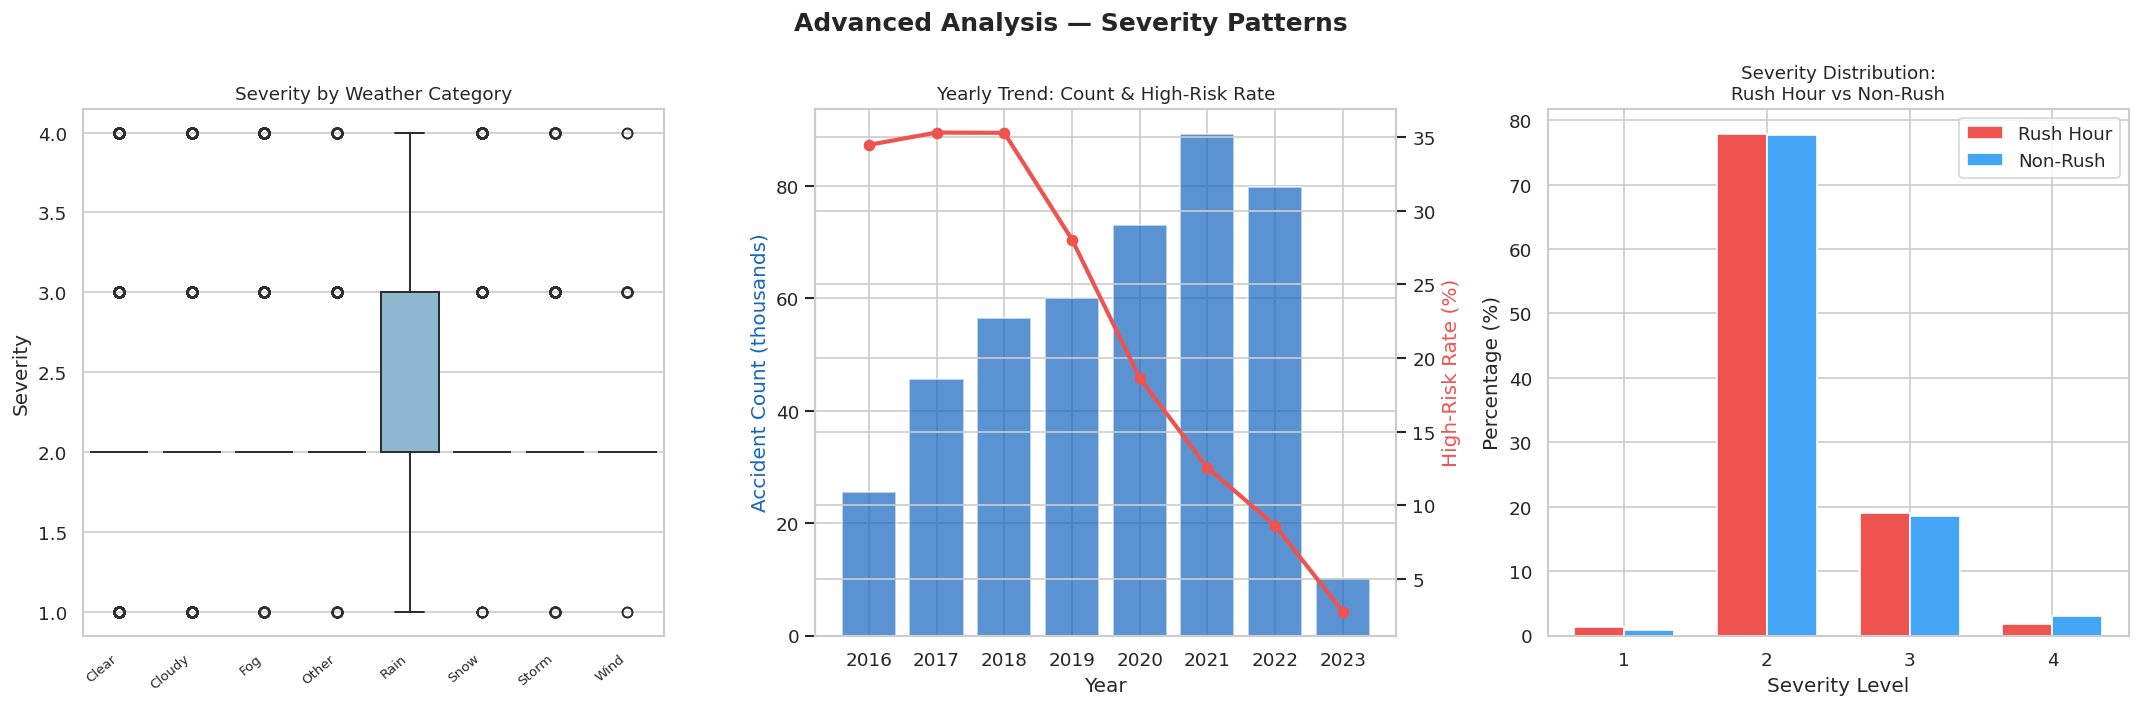

 Advanced panel saved!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Advanced Analysis — Severity Patterns", fontsize=15, fontweight="bold")

# 1) Severity by Weather — Boxplot
ax = axes[0]
weather_order = df.groupby("WeatherCategory")["Severity"].median().sort_values(ascending=False).index.tolist()


sns.boxplot(data=df, x="WeatherCategory", y="Severity",
            order=weather_order, ax=ax,
            palette="Blues_r", linewidth=1.2)
ax.set_title("Severity by Weather Category", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("Severity")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)

# 2) Yearly accident trend
ax = axes[1]
yearly = df.groupby("Year").agg(
    count=("Severity","count"),
    high_risk=("HighRisk","mean")
).reset_index()
yearly = yearly[yearly["Year"].between(2016, 2023)]

color1 = "#1565C0"
color2 = "#EF5350"
ax2 = ax.twinx()
ax.bar(yearly["Year"], yearly["count"]/1000, color=color1, alpha=0.7, label="Count (K)")
ax2.plot(yearly["Year"], yearly["high_risk"]*100, color=color2,
         marker="o", linewidth=2.5, label="High-Risk %")
ax.set_xlabel("Year")
ax.set_ylabel("Accident Count (thousands)", color=color1)
ax2.set_ylabel("High-Risk Rate (%)", color=color2)
ax.set_title("Yearly Trend: Count & High-Risk Rate", fontsize=11)
ax.set_xticks(yearly["Year"])

# 3) Rush hour vs normal — severity distribution
ax = axes[2]
rush_sev    = df[df["IsRushHour"]]["Severity"].value_counts(normalize=True).sort_index() * 100
nonrush_sev = df[~df["IsRushHour"]]["Severity"].value_counts(normalize=True).sort_index() * 100

x = np.arange(1, 5)
width = 0.35
ax.bar(x - width/2, rush_sev.reindex([1,2,3,4], fill_value=0),
       width, label="Rush Hour", color="#EF5350", edgecolor="white")
ax.bar(x + width/2, nonrush_sev.reindex([1,2,3,4], fill_value=0),
       width, label="Non-Rush", color="#42A5F5", edgecolor="white")
ax.set_title("Severity Distribution:\nRush Hour vs Non-Rush", fontsize=11)
ax.set_xlabel("Severity Level")
ax.set_ylabel("Percentage (%)")
ax.set_xticks(x)
ax.legend()

plt.tight_layout()
plt.savefig("figures/eda_panel4_advanced.png", bbox_inches="tight", dpi=150)
plt.show()
print(" Advanced panel saved!")

###  Panel 4 Key Findings
- **Weather boxplot:** Snow and Rain show higher median severity than Clear conditions
- **Yearly trend:** Accident counts grew significantly from 2016 to 2021, slight decrease after — reflects dataset coverage and reporting improvements
- **Rush vs Non-Rush:** Rush hour accidents show a slightly different severity distribution, with more Severity 2 cases — high volume but moderate impact